In [1]:
import gzip
from io import BytesIO
from time import sleep

import numpy as np
import pandas
import pandas as pd
import os
import requests
import json
import csv
import shutil
from datetime import date, timedelta

from pandas import concat
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [3]:
from preprocessing_utils import preprocess_NVD_data

In [4]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# EPSS data

Download the EPSS data from https://www.first.org/epss/data_stats into `data` folder

In [5]:
base_url = "https://epss.empiricalsecurity.com/epss_scores-"
date_current = str(date.today() - timedelta(days=1))
epss_url = base_url + date_current + ".csv.gz"
epss_filename = "epss_scores-latest.csv"

response = requests.get(epss_url)
if response.status_code != 200:
    print("Error:", response.status_code)
else:
    with open(os.path.join(data_path, epss_filename), "wb") as f:
        f.write(gzip.decompress(response.content))

In [6]:
epss_current = pd.read_csv(os.path.join(data_path, epss_filename), header=1)
epss_current  # a Python statement with a variable name at the end of a cell will display its contents below


,cve,epss,percentile
0,CVE-1999-0001,0.01151,0.78020
1,CVE-1999-0002,0.10546,0.93015
2,CVE-1999-0003,0.89352,0.99521
3,CVE-1999-0004,0.03037,0.86249
4,CVE-1999-0005,0.13652,0.94021
...,...,...,...
308071,CVE-2025-9994,0.00114,0.30855
308072,CVE-2025-9996,0.00241,0.47334
308073,CVE-2025-9997,0.00245,0.47699
308074,CVE-2025-9998,0.00022,0.05357


# NVD data

In [7]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z'  # Do NOT change these dates
date_end_NVD = '2025-10-01T00:00:00.000Z'  # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1

candidate_cves = []
while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break
    data = response.json()
    total_results = data.get("totalResults", 0)
    candidate_cves.extend(data.get("vulnerabilities", []))
    start_index += results_per_page
    print(start_index)

1000
2000
3000
4000
5000


In [8]:
# normalize and preprocess data
candidate_cves_df = pd.json_normalize(candidate_cves, record_path=None, sep='.', max_level=None)
candidate_cves_df = preprocess_NVD_data(candidate_cves_df)

# remove vulnerabilities marked as "reject" or "reserved"
candidate_cves_df = candidate_cves_df[
    (candidate_cves_df['cve.vulnStatus'] != 'Reserved') & (candidate_cves_df['cve.vulnStatus'] != 'Reject')]

# merge NVD and EPSS data
candidate_cves_df = candidate_cves_df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [9]:
candidate_cves_df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2025-09-08 14:06:05.217000,2025-09-04 18:47:25.440000
cve.vulnStatus,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN
cve.cisaRequiredAction,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN


- show a bar plot with the daily volume of published CVEs

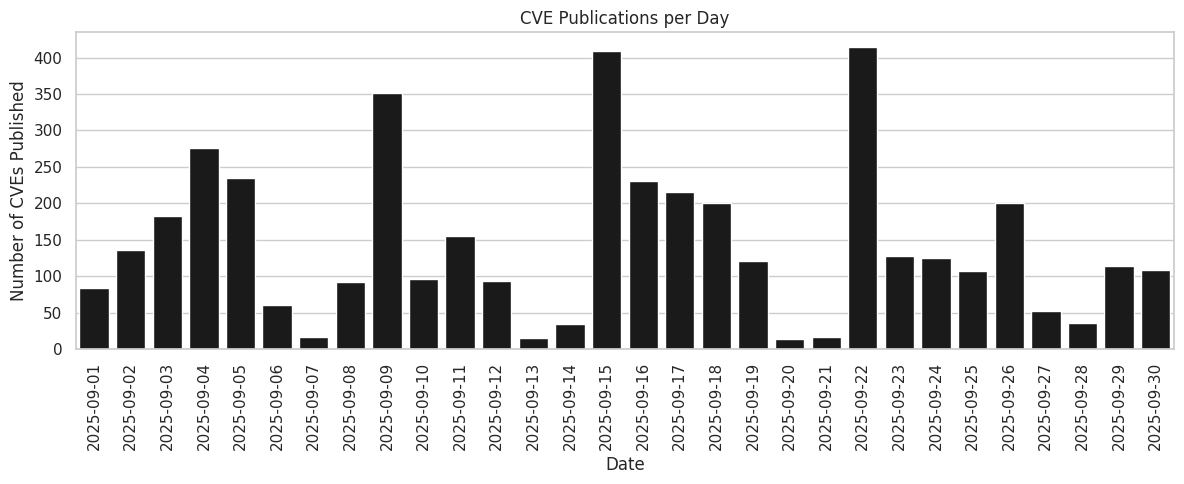

In [10]:
published_counts = candidate_cves_df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k")
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

- print the description of the last ten published vulnerabilities

In [11]:
for idx, x in enumerate(candidate_cves_df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-' * 100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

We keep track of some information to help us later on.

In [12]:
dropped_columns = []

- What is the percentage of CVEs which received a CVSS score?

In [13]:
print(f"{(candidate_cves_df["cvss_baseScore"].count() / len(candidate_cves_df)) * 100:.02f}%")

92.90%


- Report descriptive statistics of CVSS the CVSS base score and/or show its distribution

In [14]:
candidate_cves_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322 entries, 0 to 4321
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cve.id                      4322 non-null   object        
 1   cve.sourceIdentifier        4322 non-null   object        
 2   cve.published               4322 non-null   datetime64[ns]
 3   cve.lastModified            4322 non-null   datetime64[ns]
 4   cve.vulnStatus              4322 non-null   object        
 5   cve.references              4322 non-null   object        
 6   cve.cisaExploitAdd          14 non-null     object        
 7   cve.cisaActionDue           14 non-null     object        
 8   cve.cisaRequiredAction      14 non-null     object        
 9   cve.cisaVulnerabilityName   14 non-null     object        
 10  description                 4322 non-null   object        
 11  vulnerable_cpes             4322 non-null   object      

We see that feature 6, 7, 8, and 9 have a very small amount of non null values. Therefore, we drop those columns to reduce dimensionality. We also remove all CVEs withtout CVSS data.

In [15]:
dropped_columns = ["cve.cisaExploitAdd", "cve.cisaActionDue", "cve.cisaRequiredAction", "cve.cisaVulnerabilityName"]
candidate_cves_df = candidate_cves_df.drop(columns=dropped_columns).dropna()

Here we print some statistics about CVSS base score and we show its distribution related to publication date.

In [16]:
candidate_cves_df["cvss_baseScore"].describe()

count    4015.000000
mean        6.773898
std         1.735108
min         2.200000
25%         5.500000
50%         6.500000
75%         7.800000
max        10.000000
Name: cvss_baseScore, dtype: float64

<Figure size 1200x500 with 0 Axes>

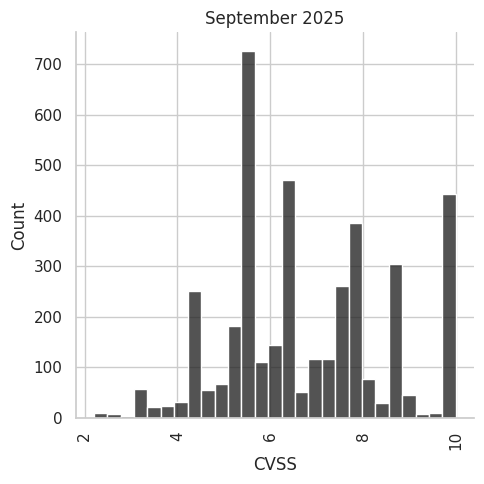

In [17]:
plt.figure(figsize=(12, 5))
sns.displot(x=candidate_cves_df["cvss_baseScore"], color="k")
plt.xticks(rotation=90)
plt.xlabel("CVSS")
plt.ylabel("Count")
plt.title("September 2025")
plt.tight_layout()
plt.show()

It would seem that a relatively high number of CVEs published in september 2025 have a very high CVSS.

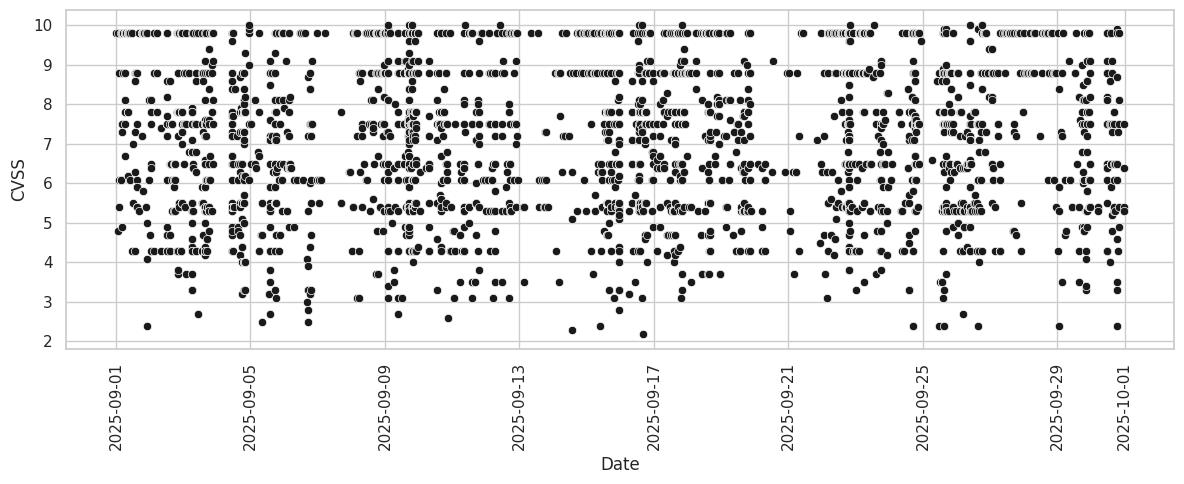

In [18]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=candidate_cves_df["cve.published"], y=candidate_cves_df["cvss_baseScore"], color="k")
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("CVSS")
plt.tight_layout()
plt.show()


- #### Report descriptive statistics of EPSS and/or show its distribution

Here we print some statistics about EPSS base score and we show its distribution related to publication date.

In [19]:
candidate_cves_df["epss"].describe()

count    4015.000000
mean        0.002853
std         0.030654
min         0.000020
25%         0.000190
50%         0.000410
75%         0.000570
max         0.831590
Name: epss, dtype: float64

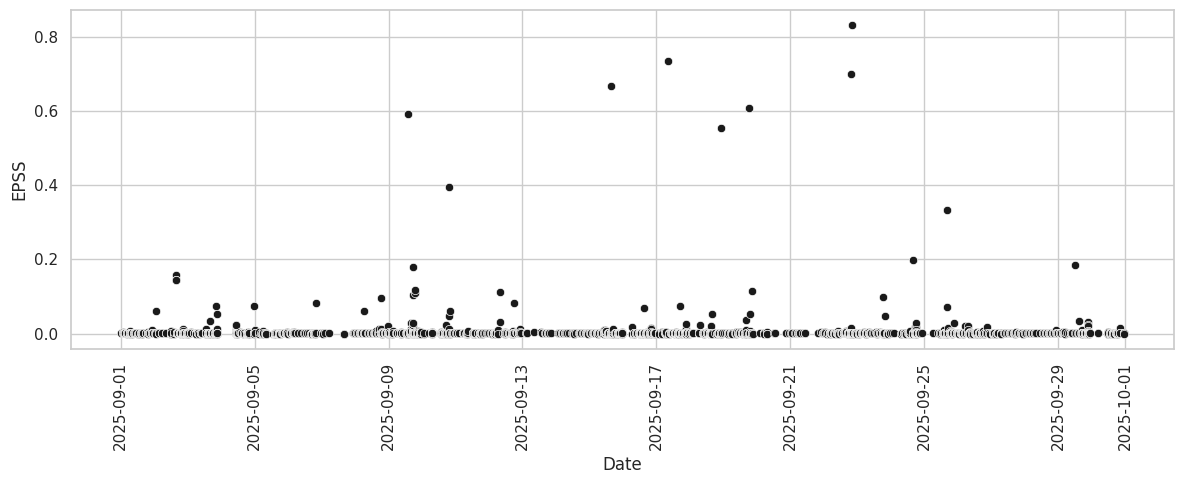

In [20]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=candidate_cves_df["cve.published"], y=candidate_cves_df["epss"], color="k")
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("EPSS")
plt.tight_layout()
plt.show()


It is evident that, except for a couple of outliers, on average the EPSS is extremely low.

- #### Produce a scatter plot showing CVSS vs EPSS


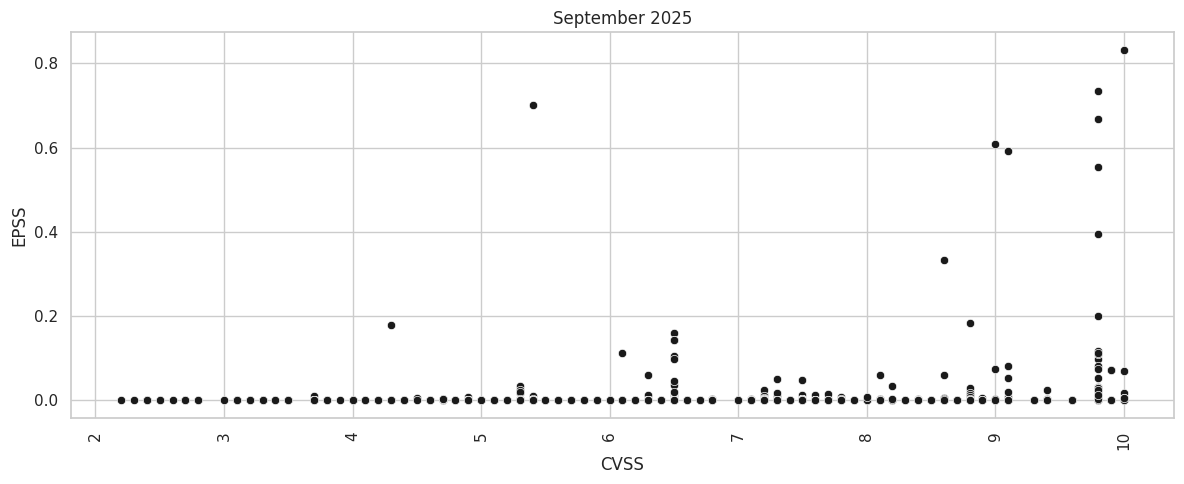

In [21]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=candidate_cves_df["cvss_baseScore"], y=candidate_cves_df["epss"], color="k")
plt.xticks(rotation=90)
plt.xlabel("CVSS")
plt.ylabel("EPSS")
plt.title("September 2025")
plt.tight_layout()
plt.show()

As we can see, the CVSS and EPSS are not really related with each other, even though the only times the EPSS is high enough, it's in the presence of an equally high CVSS. We can further visualize this lack of correlation with a correlation matrix:

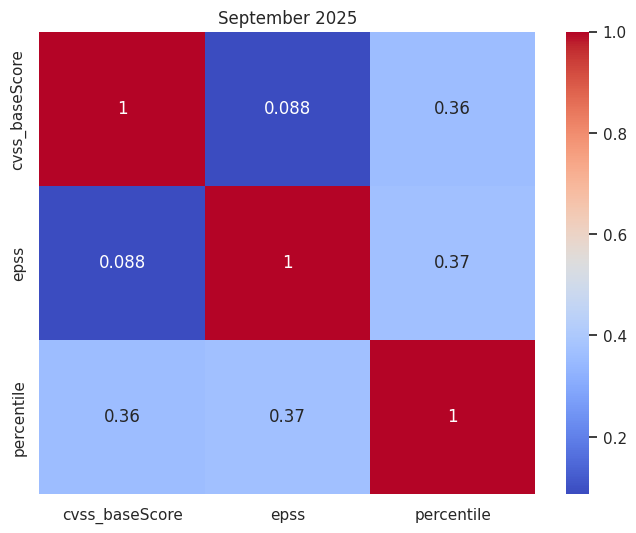

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(candidate_cves_df[["cvss_baseScore", "epss", "percentile"]].corr(), annot=True, cmap="coolwarm")
plt.title("September 2025")
plt.show()

- #### Extra analysis - Top 20 most frequent vendors

In [23]:
vendor = (
    candidate_cves_df['vulnerable_cpes']
      .astype(str)
      .str.strip()
      .str.split(':')
      .str[3]
      .replace('', np.nan)
)


vendor_counts = (
    vendor
    .dropna()
    .value_counts(dropna=False)
    .rename_axis('vendor')
    .reset_index(name='count')
)

vendor_counts = vendor_counts.sort_values('count', ascending=False)

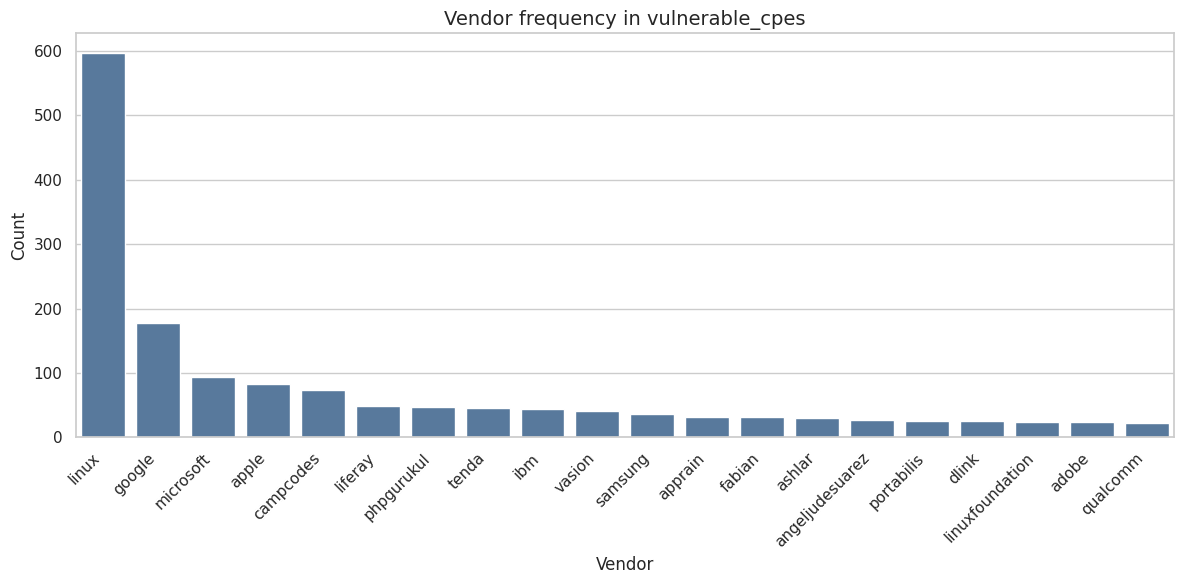

In [24]:
plt.figure(figsize=(12, 6))
top_n = 20
plot_df = vendor_counts.head(top_n)

ax = sns.barplot(data=plot_df, x='vendor', y='count', color='#4C78A8')
ax.set_title('Vendor frequency in vulnerable_cpes', fontsize=14)
ax.set_xlabel('Vendor', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As per specification, we start by filtering the CVEs with low EPSS (<1%), removing all features we will not need, and turning the remaining ones into categorical.

In [23]:
candidate_cves_df = candidate_cves_df[candidate_cves_df['percentile'] <= 0.01].drop(columns=["epss", "percentile", "cve", "cve.published", "cve.lastModified", "cvss_version", "cve.references", "num_references", "vulnerable_cpes"])

In [24]:
cols_to_cat = ["cve.sourceIdentifier", "cve.vulnStatus", "cvss_vectorString", "cvss_baseSeverity", "cvss_attackVector",
               "cvss_attackComplexity", "cvss_privilegesRequired", "cvss_userInteraction", "cvss_scope",
               "cvss_confidentialityImpact", "cvss_integrityImpact",
               "cvss_availabilityImpact"]
candidate_cves_df[cols_to_cat] = candidate_cves_df[cols_to_cat].astype('category')
candidate_cves_df.info()
# save the final dataframe
candidate_cves_df.to_csv(os.path.join(data_path, "candidate_cves_df.csv"))

<class 'pandas.core.frame.DataFrame'>
Index: 167 entries, 20 to 4304
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   cve.id                      167 non-null    object  
 1   cve.sourceIdentifier        167 non-null    category
 2   cve.vulnStatus              167 non-null    category
 3   description                 167 non-null    object  
 4   cwe_list                    167 non-null    object  
 5   cvss_vectorString           167 non-null    category
 6   cvss_baseScore              167 non-null    float64 
 7   cvss_baseSeverity           167 non-null    category
 8   cvss_attackVector           167 non-null    category
 9   cvss_attackComplexity       167 non-null    category
 10  cvss_privilegesRequired     167 non-null    category
 11  cvss_userInteraction        167 non-null    category
 12  cvss_scope                  167 non-null    category
 13  cvss_confidentialityImp

## Downloading NVD 2022-2025 database
We start by downloading all the CVEs that have been published between 2022 and 2024. This is because EPSS data is only available from 2021, and since we want to analyze CVEs behavior from when they were published, we need CVEs from after 2021.

In [26]:
base_url = "https://nvd.nist.gov/feeds/json/cve/2.0/nvdcve-2.0-"
ext = ".json.gz"
NVD_API_KEY = "c13c3940-8ebd-4073-ad37-d2507719f385" # insert your key

base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
cve_date_start = date(2022, 1, 1)
cve_date_end = date(2025, 6, 1)
cve_window_start = cve_date_start
cves = []

while cve_window_start + timedelta(days=30) <= cve_date_end:
    start_index = 0
    results_per_page = 1000
    total_results = 1
    date_start_NVD = f'{cve_window_start}T00:00:00.001Z'
    date_end_NVD = f'{cve_window_start + timedelta(days=30)}T00:00:00.000Z'
    print(f"Downloading CVEs between {date_start_NVD} and {date_end_NVD}...")
    while start_index < total_results:
        params = {
            "pubStartDate": date_start_NVD,
            "pubEndDate": date_end_NVD,
            "resultsPerPage": results_per_page,
            "startIndex": start_index,
            "noRejected": "",
            #"apiKey": NVD_API_KEY
        }
        response = requests.get(base_url, params=params, timeout=6)
        if response.status_code != 200:
            print("Error:", response.status_code)
            break
        data = response.json()
        total_results = data.get("totalResults", 0)
        cves.extend(data.get("vulnerabilities", []))
        start_index += results_per_page
        print(start_index)
        sleep(1)
    sleep(5)
    cve_window_start += timedelta(days=30)

1000
2000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
1000
2000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
4000
1000
2000
3000
4000
5000
1000
2000
3000
4000
5000
1000
2000
3000
4000
1000
2000
3000
4000
1000
2000
3000
1000
2000
3000
1000
2000
3000
1000
2000
3000
4000
5000
1000
2000
3000
4000
1000
2000
3000
4000
1000
2000
3000
4000
1000
2000
3000
4000
1000
2000
3000
4000
5000
1000
2000
3000
4000
Error: 429


In [27]:
# normalize and preprocess data
cves_df = pd.json_normalize(cves, record_path=None, sep='.', max_level=None)
cves_df = preprocess_NVD_data(cves_df)

In [28]:
# remove vulnerabilities marked as "reject" or "reserved"
cves_df = cves_df[(cves_df['cve.vulnStatus'] != 'Reserved') & (cves_df['cve.vulnStatus'] != 'Reject')]

In [29]:
cves_df.describe()

,cve.published,cve.lastModified,num_references,cvss_baseScore
count,111888,111888,111888.000000,111053.000000
mean,2023-11-29 17:34:50.145608192,2025-02-08 05:55:14.759742208,3.717905,7.004528
min,2022-01-01 00:15:08.057000,2024-07-31 12:57:02.300000,1.000000,0.000000
25%,2023-02-08 19:15:11.409250048,2024-11-21 07:19:55.312499968,2.000000,5.500000
50%,2024-01-24 02:45:07.666500096,2024-11-21 09:32:53.486500096,2.000000,7.100000
75%,2024-10-11 13:15:16.226999808,2025-04-15 18:02:13.699749888,4.000000,8.100000
max,2025-05-14 20:15:21.927000,2025-12-24 14:15:46.227000,287.000000,10.000000
std,NaN,NaN,3.660688,1.704474


In [30]:
cves_df.isnull().sum()

cve.id                             0
cve.sourceIdentifier               0
cve.published                      0
cve.lastModified                   0
cve.vulnStatus                     0
cve.references                     0
cve.cisaExploitAdd            111365
cve.cisaActionDue             111365
cve.cisaRequiredAction        111365
cve.cisaVulnerabilityName     111365
cve.evaluatorComment          111878
description                        0
vulnerable_cpes                    0
num_references                     0
cwe_list                           0
cvss_version                     835
cvss_vectorString                835
cvss_baseScore                   835
cvss_baseSeverity                837
cvss_attackVector                835
cvss_attackComplexity            835
cvss_privilegesRequired          835
cvss_userInteraction             835
cvss_scope                       835
cvss_confidentialityImpact       835
cvss_integrityImpact             835
cvss_availabilityImpact          835
d

Some features have a high number of missing values, so we drop the columns directly. Due to the sheer amount of samples, we also remove all the rows that have a missing value. Since we will aggregate data from all the CVEs' histories, we also drop date-related columns.

In [61]:
X = cves_df.drop(columns=["cve.cisaExploitAdd", "cve.evaluatorComment", "cve.cisaActionDue", "cve.cisaRequiredAction",
                          "cve.cisaVulnerabilityName", "cve.published", "cve.lastModified"]).dropna()
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111051 entries, 0 to 111887
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   cve.id                      111051 non-null  object  
 1   cve.sourceIdentifier        111051 non-null  object  
 2   cve.vulnStatus              111051 non-null  object  
 3   cve.references              111051 non-null  object  
 4   description                 111051 non-null  object  
 5   vulnerable_cpes             111051 non-null  object  
 6   num_references              111051 non-null  int64   
 7   cwe_list                    111051 non-null  object  
 8   cvss_version                111051 non-null  object  
 9   cvss_vectorString           111051 non-null  object  
 10  cvss_baseScore              111051 non-null  float64 
 11  cvss_baseSeverity           111051 non-null  category
 12  cvss_attackVector           111051 non-null  object  
 13  cvss

In [62]:
X.head(3).T

,0,1,2
cve.id,CVE-2021-45929,CVE-2021-45944,CVE-2021-45946
cve.sourceIdentifier,cve@mitre.org,cve@mitre.org,cve@mitre.org
cve.vulnStatus,Modified,Modified,Modified
cve.references,[{'url': 'https://bugs.chromium.org/p/oss-fuzz...,[{'url': 'https://bugs.chromium.org/p/oss-fuzz...,[{'url': 'https://bugs.chromium.org/p/oss-fuzz...
description,Wasm3 0.5.0 has an out-of-bounds write in Comp...,Ghostscript GhostPDL 9.50 through 9.53.3 has a...,Wasm3 0.5.0 has an out-of-bounds write in Comp...
vulnerable_cpes,[cpe:2.3:a:wasm3_project:wasm3:0.5.0:*:*:*:*:*...,[cpe:2.3:a:artifex:ghostscript:*:*:*:*:*:*:*:*...,[cpe:2.3:a:wasm3_project:wasm3:0.5.0:*:*:*:*:*...
num_references,4,14,4
cwe_list,[CWE-787],[CWE-416],[CWE-787]
cvss_version,3.1,3.1,3.1
cvss_vectorString,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:N/I:N/A:H,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:N/I:N/A:H,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:N/I:N/A:H


Since all CVEs share the same CVSS version, we can remove that column from our dataset.

In [63]:
X = X.drop(columns="cvss_version")

Even though the number of references and cpes could be very useful, since they refer to the status of the CVE at the moment of download and do not contain time series data, we cannot use them to asses how the CVE evolved during its first months after publication. For this reason, we drop those columns too from our dataset.

In [64]:
X = X.drop(columns=["cve.references", "num_references", "vulnerable_cpes"])


We now transform all remaining variables into categorial ones.

In [65]:
cols_to_cat = ["cve.sourceIdentifier", "cve.vulnStatus", "cvss_vectorString", "cvss_baseSeverity", "cvss_attackVector",
               "cvss_attackComplexity", "cvss_privilegesRequired", "cvss_userInteraction", "cvss_scope",
               "cvss_confidentialityImpact", "cvss_integrityImpact",
               "cvss_availabilityImpact"]
X[cols_to_cat] = X[cols_to_cat].astype('category')

In [66]:
X.to_csv(os.path.join(data_path, "cves_df.csv"))

## Downloading historical EPSS data

For each CVE, we download its complete EPSS history. We take all CVEs that started with a percentile value < 1% and we calculate the following metrics for their first 3 months after publication:
- $\frac{\sum_{t=1}^{T}pct_{i,t}-pct_{i,0}}{T}, T = 90$
- $\text{max}_t(pct_{i,t}-pct_{i,0}), t\in[1,...,90]$

In [37]:
window = 90

start_date = date(2022, 1, 1)
end_date = date(2025, 6, 1) + timedelta(days=window)
epss_path = os.path.join(data_path, "epss_history")
os.makedirs(epss_path, exist_ok=True)
while start_date <= end_date:
    url = "https://epss.empiricalsecurity.com/epss_scores-{:%Y-%m-%d}.csv.gz".format(start_date)
    filename = os.path.join(epss_path, f"epss_scores-{start_date:%Y-%m-%d}.csv.gz")

    # Skip if already downloaded
    if os.path.exists(filename):
        print(f"Skipping {filename} (already exists)")
    else:
        print(f"Downloading {url}...")
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, "wb") as f:
                f.write(response.content)
            print(f"Saved to {filename}")
        else:
            print(f"No file for {start_date:%Y-%m-%d} (HTTP {response.status_code})")
        sleep(1)
    start_date += timedelta(days=1)

print("Download complete.")

Saved to data/epss_history/epss_scores-2022-01-01.csv.gz
Saved to data/epss_history/epss_scores-2022-01-02.csv.gz
Saved to data/epss_history/epss_scores-2022-01-03.csv.gz
Saved to data/epss_history/epss_scores-2022-01-04.csv.gz
Saved to data/epss_history/epss_scores-2022-01-05.csv.gz
Saved to data/epss_history/epss_scores-2022-01-06.csv.gz
Saved to data/epss_history/epss_scores-2022-01-07.csv.gz
Saved to data/epss_history/epss_scores-2022-01-08.csv.gz
Saved to data/epss_history/epss_scores-2022-01-09.csv.gz
Saved to data/epss_history/epss_scores-2022-01-10.csv.gz
Saved to data/epss_history/epss_scores-2022-01-11.csv.gz
Saved to data/epss_history/epss_scores-2022-01-12.csv.gz
Saved to data/epss_history/epss_scores-2022-01-13.csv.gz
Saved to data/epss_history/epss_scores-2022-01-14.csv.gz
Saved to data/epss_history/epss_scores-2022-01-15.csv.gz
Saved to data/epss_history/epss_scores-2022-01-16.csv.gz
Saved to data/epss_history/epss_scores-2022-01-17.csv.gz
Saved to data/epss_history/epss

In [38]:
# Loop through all .gz files
for filename in os.listdir(epss_path):
    gz_path = os.path.join(epss_path, filename)
    csv_path = os.path.join(epss_path, filename[:-3])  # Remove .gz
    if filename.endswith(".csv.gz") and not os.path.exists(csv_path):
        print(f"Unzipping {gz_path} -> {csv_path}")
        with gzip.open(gz_path, "rb") as f_in:
            with open(csv_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

print("All files unzipped successfully.")

Unzipping data/epss_history/epss_scores-2022-01-01.csv.gz -> data/epss_history/epss_scores-2022-01-01.csv
Unzipping data/epss_history/epss_scores-2022-01-02.csv.gz -> data/epss_history/epss_scores-2022-01-02.csv
Unzipping data/epss_history/epss_scores-2022-01-03.csv.gz -> data/epss_history/epss_scores-2022-01-03.csv
Unzipping data/epss_history/epss_scores-2022-01-04.csv.gz -> data/epss_history/epss_scores-2022-01-04.csv
Unzipping data/epss_history/epss_scores-2022-01-05.csv.gz -> data/epss_history/epss_scores-2022-01-05.csv
Unzipping data/epss_history/epss_scores-2022-01-06.csv.gz -> data/epss_history/epss_scores-2022-01-06.csv
Unzipping data/epss_history/epss_scores-2022-01-07.csv.gz -> data/epss_history/epss_scores-2022-01-07.csv
Unzipping data/epss_history/epss_scores-2022-01-08.csv.gz -> data/epss_history/epss_scores-2022-01-08.csv
Unzipping data/epss_history/epss_scores-2022-01-09.csv.gz -> data/epss_history/epss_scores-2022-01-09.csv
Unzipping data/epss_history/epss_scores-2022-0

We create a dictionary containing as keys all the CVEs published between 2022 and 2024, and as values a list of their first 90 percentile values since first publication on EPSS.

In [49]:
percentiles_history = {}
r = 0
p = 0
# Loop through all CSV files
for filename in sorted(os.listdir(epss_path)):
    if filename.endswith(".csv") and filename.startswith("epss_scores-"):
        file_path = os.path.join(epss_path, filename)
        # Read file and acquire CVEs
        with open(file_path, newline='', encoding="utf-8") as csvfile:
            reader = csv.reader(csvfile)
            print(f"Reading {filename}...")
            for row in reader:
                if len(row) >= 3 and row[0].strip().startswith(("CVE-2022", "CVE-2023", "CVE-2024", "CVE-2025")):
                    r += 1
                    if row[0].strip() not in percentiles_history:
                        percentiles_history[row[0].strip()] = []
                        if float(row[2].strip()) < 0.01:
                            p += 1
                    percentiles_history[row[0].strip()].append(float(row[2].strip()))

# We cap the percentiles at the first 90 days
for cve in percentiles_history:
    percentiles_history[cve] = percentiles_history[cve][0:90]

Reading epss_scores-2022-01-01.csv...
Reading epss_scores-2022-01-02.csv...
Reading epss_scores-2022-01-03.csv...
Reading epss_scores-2022-01-04.csv...
Reading epss_scores-2022-01-05.csv...
Reading epss_scores-2022-01-06.csv...
Reading epss_scores-2022-01-07.csv...
Reading epss_scores-2022-01-08.csv...
Reading epss_scores-2022-01-09.csv...
Reading epss_scores-2022-01-10.csv...
Reading epss_scores-2022-01-11.csv...
Reading epss_scores-2022-01-12.csv...
Reading epss_scores-2022-01-13.csv...
Reading epss_scores-2022-01-14.csv...
Reading epss_scores-2022-01-15.csv...
Reading epss_scores-2022-01-16.csv...
Reading epss_scores-2022-01-17.csv...
Reading epss_scores-2022-01-18.csv...
Reading epss_scores-2022-01-19.csv...
Reading epss_scores-2022-01-20.csv...
Reading epss_scores-2022-01-21.csv...
Reading epss_scores-2022-01-22.csv...
Reading epss_scores-2022-01-23.csv...
Reading epss_scores-2022-01-24.csv...
Reading epss_scores-2022-01-25.csv...
Reading epss_scores-2022-01-26.csv...
Reading epss

In [67]:
print(f"N of entries: {r}\n N of 1%: {p}")

N of entries: 63880638
 N of 1%: 715


## Feature Construction using EPSS data

In [68]:
def get_first_percentile(cveid):
    if cveid in percentiles_history:
        return percentiles_history[cveid][0]
    return None

In [70]:
X = X[X["cve.id"].apply(lambda c: c in percentiles_history)]

$$\text{mean\_daily\_gain} = \frac{\sum_{t=1}^{T}pct_{i,t}-pct_{i,0}}{T} = \frac{(\sum_{t=1}^{T}pct_{i,t})-(T-1)pct_{i,0}}{T},  T = 90$$

In [53]:
def mean_daily_gain(values):
    return (sum(values[1:-1]) - (len(values)-1)*values[0]) / len(values)

$$\text{total\_gain}=\text{max}_t(pct_{i,t}-pct_{i,0}), t\in[1,...,90]$$

In [55]:
def total_gain(values):
    res = 0
    for value in values[1:-1]:
        res = max(res, value - values[0])
    return res

In [72]:
# merge NVD and derivative metrics
X['initial_percentile'] = X["cve.id"].apply(get_first_percentile)
X['mean_daily_gain'] = X["cve.id"].apply(lambda c: mean_daily_gain(percentiles_history[c]))
X['total_gain'] = X["cve.id"].apply(lambda c: total_gain(percentiles_history[c]))
# save the final dataframe
X.to_csv(os.path.join(data_path, "cves_df.csv"))

As we can see from the following plots, CVEs tend to start with an EPSS score sitting in the 10%. It is also evident how the mean daily gain and total gain over the first 90 days after publishing sit close to zero, meaning the vast majority of CVEs do not increase their threat level.

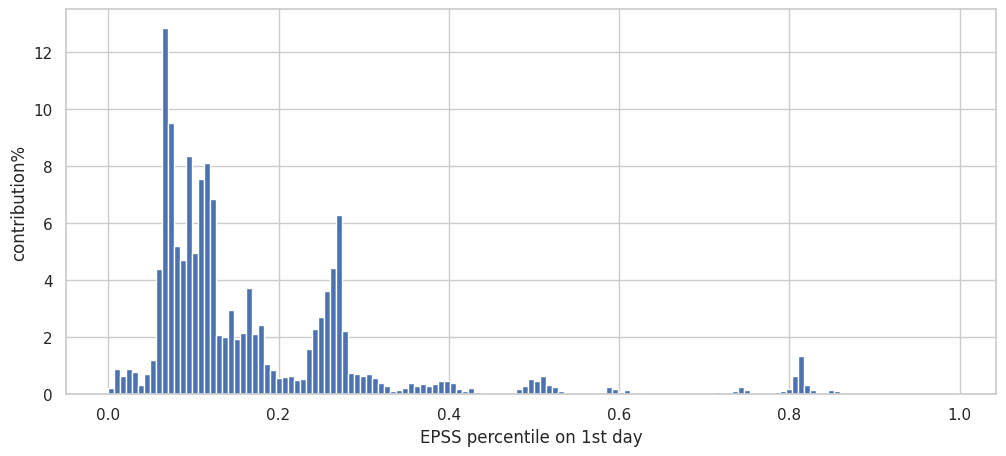

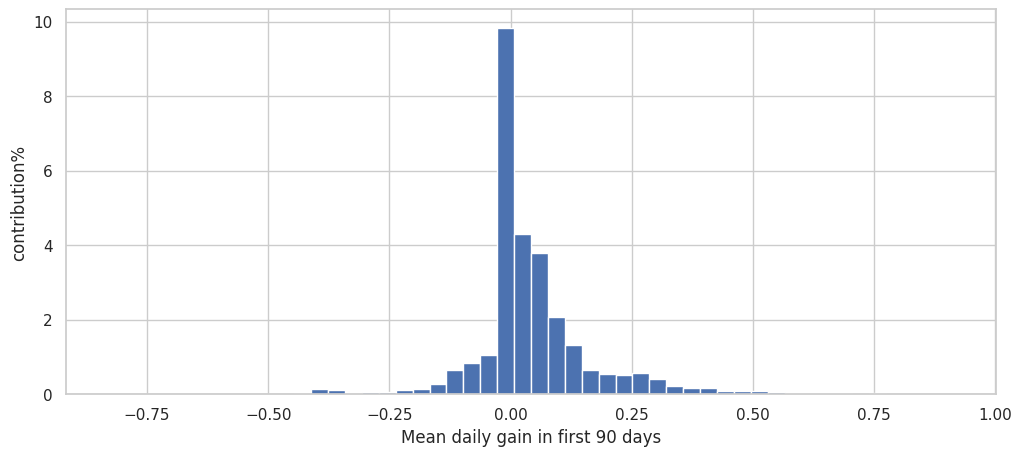

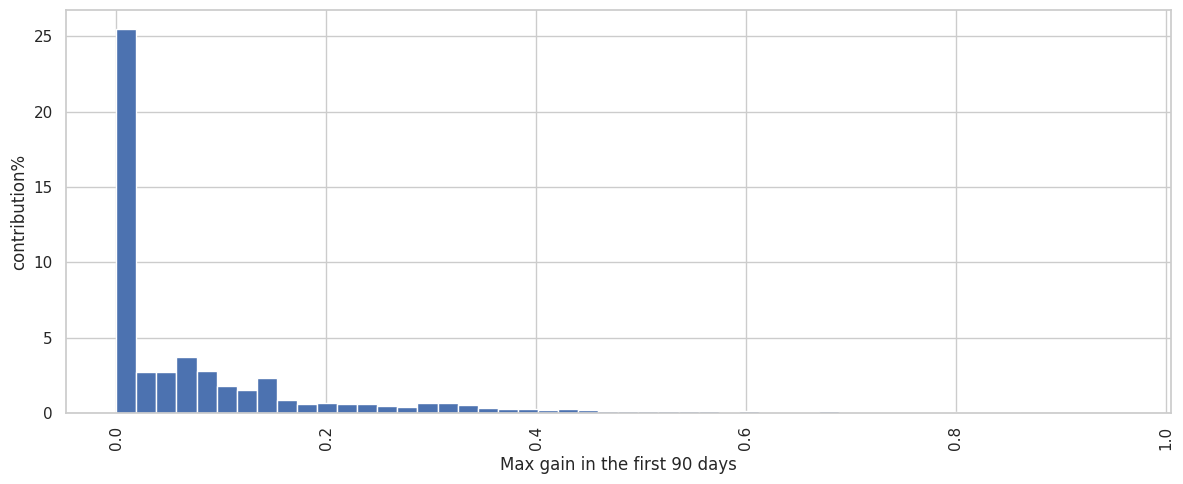

In [73]:
plt.figure(figsize=(12, 5))
plt.ylabel("contribution%")
plt.hist(X["initial_percentile"], bins="auto", density=True)
plt.xlabel("EPSS percentile on 1st day")
plt.show()

plt.figure(figsize=(12, 5))
plt.ylabel("contribution%")
plt.hist(X["mean_daily_gain"], bins=50, density=True)
plt.xlabel("Mean daily gain in first 90 days")
plt.show()

plt.figure(figsize=(12, 5))
plt.ylabel("contribution%")
plt.hist(x=X["total_gain"], bins=50, density=True)
plt.xlabel("Max gain in the first 90 days")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [81]:
X[X["initial_percentile"] < 0.01].info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 30171 to 111884
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   cve.id                      303 non-null    object  
 1   cve.sourceIdentifier        303 non-null    category
 2   cve.vulnStatus              303 non-null    category
 3   description                 303 non-null    object  
 4   cwe_list                    303 non-null    object  
 5   cvss_vectorString           303 non-null    category
 6   cvss_baseScore              303 non-null    float64 
 7   cvss_baseSeverity           303 non-null    category
 8   cvss_attackVector           303 non-null    category
 9   cvss_attackComplexity       303 non-null    category
 10  cvss_privilegesRequired     303 non-null    category
 11  cvss_userInteraction        303 non-null    category
 12  cvss_scope                  303 non-null    category
 13  cvss_confidentiali

There are only a few CVEs from 2022 to the middle of 2025 that have started with an EPSS below the 1% percentile. We will try two different ML-based approaches to select our final candidates to submit.

In [83]:
#candidate_cves_df = candidate_cves_df.drop(columns=["cve", "cve.published", "cve.lastModified", "cvss_version", "cve.references", "num_references", "vulnerable_cpes"])
candidate_cves_df.info()
candidate_cves_df.to_csv(os.path.join(data_path, "candidate_cves_df.csv"))

<class 'pandas.core.frame.DataFrame'>
Index: 167 entries, 20 to 4304
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   cve.id                      167 non-null    object  
 1   cve.sourceIdentifier        167 non-null    category
 2   cve.vulnStatus              167 non-null    category
 3   description                 167 non-null    object  
 4   cwe_list                    167 non-null    object  
 5   cvss_vectorString           167 non-null    category
 6   cvss_baseScore              167 non-null    float64 
 7   cvss_baseSeverity           167 non-null    category
 8   cvss_attackVector           167 non-null    category
 9   cvss_attackComplexity       167 non-null    category
 10  cvss_privilegesRequired     167 non-null    category
 11  cvss_userInteraction        167 non-null    category
 12  cvss_scope                  167 non-null    category
 13  cvss_confidentialityImp

# START FROM HERE IF YOU ALREADY DOWNLOADED EVERYTHING

In [84]:
import gzip
from io import BytesIO
from time import sleep

import numpy as np
import pandas
import pandas as pd
import os
import requests
import json
import csv
import shutil
from datetime import date, timedelta
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import KBinsDiscretizer
from pandas import concat
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.feature_selection import chi2
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
from preprocessing_utils import preprocess_NVD_data

data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

In [85]:
X = pd.read_csv(os.path.join(data_path, "cves_df.csv")).drop(columns="Unnamed: 0")
candidate_cves_df = pd.read_csv(os.path.join(data_path, "candidate_cves_df.csv")).drop(columns="Unnamed: 0")

In [86]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102792 entries, 0 to 102791
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   cve.id                      102792 non-null  object 
 1   cve.sourceIdentifier        102792 non-null  object 
 2   cve.vulnStatus              102792 non-null  object 
 3   description                 102792 non-null  object 
 4   cwe_list                    102792 non-null  object 
 5   cvss_vectorString           102792 non-null  object 
 6   cvss_baseScore              102792 non-null  float64
 7   cvss_baseSeverity           102792 non-null  object 
 8   cvss_attackVector           102792 non-null  object 
 9   cvss_attackComplexity       102792 non-null  object 
 10  cvss_privilegesRequired     102792 non-null  object 
 11  cvss_userInteraction        102792 non-null  object 
 12  cvss_scope                  102792 non-null  object 
 13  cvss_confident

## 1. Novelty detection on the filtered dataset

We try to train another OneClasSVM, this time on the dataset filtered by percentile < 0.01. This training set will be considered the "losers", and we hope to find some CVEs among our candidates that are detected as outliars (novel) by the SVM.

In [88]:
import sklearn
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import OneHotEncoder

In [89]:
X_train_svm = X[X["initial_percentile"] < 0.01]
X_train_svm = X_train_svm.drop(
    columns=["initial_percentile", "mean_daily_gain", "total_gain", "cve.id", "description", "cwe_list"])
X_train_svm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 24214 to 102788
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cve.sourceIdentifier        303 non-null    object 
 1   cve.vulnStatus              303 non-null    object 
 2   cvss_vectorString           303 non-null    object 
 3   cvss_baseScore              303 non-null    float64
 4   cvss_baseSeverity           303 non-null    object 
 5   cvss_attackVector           303 non-null    object 
 6   cvss_attackComplexity       303 non-null    object 
 7   cvss_privilegesRequired     303 non-null    object 
 8   cvss_userInteraction        303 non-null    object 
 9   cvss_scope                  303 non-null    object 
 10  cvss_confidentialityImpact  303 non-null    object 
 11  cvss_integrityImpact        303 non-null    object 
 12  cvss_availabilityImpact     303 non-null    object 
dtypes: float64(1), object(12)
memory 

In [90]:
X_test_svm = X[X["initial_percentile"] >= 0.01]
X_test_svm = X_test_svm.drop(
    columns=["initial_percentile", "mean_daily_gain", "total_gain", "cve.id", "description", "cwe_list"])
X_test_svm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102489 entries, 0 to 102791
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   cve.sourceIdentifier        102489 non-null  object 
 1   cve.vulnStatus              102489 non-null  object 
 2   cvss_vectorString           102489 non-null  object 
 3   cvss_baseScore              102489 non-null  float64
 4   cvss_baseSeverity           102489 non-null  object 
 5   cvss_attackVector           102489 non-null  object 
 6   cvss_attackComplexity       102489 non-null  object 
 7   cvss_privilegesRequired     102489 non-null  object 
 8   cvss_userInteraction        102489 non-null  object 
 9   cvss_scope                  102489 non-null  object 
 10  cvss_confidentialityImpact  102489 non-null  object 
 11  cvss_integrityImpact        102489 non-null  object 
 12  cvss_availabilityImpact     102489 non-null  object 
dtypes: float64(1), obje

In [91]:
encoder = OneHotEncoder()
print("Encoding categorial features...")
X_svm_encode = pd.concat(
    [X.drop(columns=["initial_percentile", "mean_daily_gain", "total_gain", "cve.id", "description", "cwe_list"]),
     candidate_cves_df.drop(columns=["cve.id", "description", "cwe_list"])])
encoder.fit(X_svm_encode)
X_train_svm_encoded = encoder.transform(X_train_svm)
X_test_svm_encoded = encoder.transform(X_test_svm)

Encoding categorial features...


In [92]:
estimator = OneClassSVM()
print("Fitting model...")
estimator.fit(X_train_svm_encoded)

Fitting model...


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.5
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [93]:
print("Testing...")
y_svm_test = estimator.predict(X_test_svm_encoded)
print(f"Accuracy on testing data: {len(y_svm_test[y_svm_test == -1]) / len(X_test_svm)}%")

Testing...
Accuracy on testing data: 0.8370166554459503%


In [94]:
candidate_cves_df_encoded = encoder.transform(candidate_cves_df.drop(columns=["cve.id", "description", "cwe_list"]))
print("Predicting...")
y_svm_predict = estimator.predict(candidate_cves_df_encoded)
print(f"Outliars in candidates: {100 * len(y_svm_predict[y_svm_predict == -1]) / len(y_svm_predict):.02f}%")
y_svm_predict = ["Outlier" if p == -1 else "Inlier" for p in y_svm_predict]
print(y_svm_predict)

Predicting...
Outliars in candidates: 31.14%
['Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Inlier', 'Outlier', 'Inlier', 'Inlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Outlier', 'Outlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Outlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Outlier', 'Outlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier', 'Inlier'

## 2 Metrics prediction on the filtered dataset

We try to train a RandomForestRegressor on the dataset filtered by percentile < 0.01.

In [95]:
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, accuracy_score

In [96]:
encoder = OneHotEncoder()
print("Encoding categorial features...")
X_rr_features = X[X["initial_percentile"] < 0.01]
X_rr_features = X.drop(
    columns=["initial_percentile", "mean_daily_gain", "total_gain", "cve.id", "description", "cwe_list"])
X_rr_encode = pd.concat([X_rr_features, candidate_cves_df.drop(columns=["cve.id", "description", "cwe_list"])])
encoder.fit(X_rr_encode)
X_rr_features_encoded = encoder.transform(X_rr_features)
print("Generating train/test split...")
targets = ["mean_daily_gain", "total_gain"]
y_rr_targets = X[targets]
X_rr_train, X_rr_test, y_rr_train, y_rr_test = train_test_split(X_rr_features_encoded,
                                                                y_rr_targets,
                                                                test_size=0.33,
                                                                random_state=42)

Encoding categorial features...
Generating train/test split...


In [97]:
print("Fitting model...")
rr = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
estimator = MultiOutputRegressor(rr)
estimator.fit(X_rr_train, y_rr_train)

Fitting model...


,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at leas

In [98]:
print("Testing...")
y_rr_predict = estimator.predict(X_rr_test)
print("R^2 per target:", r2_score(y_rr_test, y_rr_predict, multioutput='raw_values'))
print("MSE per target:", mean_squared_error(y_rr_test, y_rr_predict, multioutput='raw_values'))
print("RMSE per target:", root_mean_squared_error(y_rr_test, y_rr_predict, multioutput='raw_values'))

Testing...
R^2 per target: [0.27347186 0.21435853]
MSE per target: [0.01228252 0.01534275]
RMSE per target: [0.11082653 0.12386584]


In [99]:
candidate_cves_df_encoded = encoder.transform(candidate_cves_df.drop(columns=["cve.id", "description", "cwe_list"]))
print("Predicting...")
y_rr_predict = estimator.predict(candidate_cves_df_encoded)
print(y_rr_predict)

Predicting...
[[-4.08929666e-02  7.46945614e-03]
 [-4.08929666e-02  7.46945614e-03]
 [ 8.22116723e-05  1.16986846e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 7.51749494e-04  1.16767889e-02]
 [ 7.51749494e-04  1.16767889e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 3.00740512e-03  1.03757324e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 3.00740512e-03  1.03757324e-02]
 [ 7.51749494e-04  1.16767889e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 3.00740512e-03  1.03757324e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 7.51749494e-04  1.16767889e-02]
 [ 4.19983076e-03  9.84113785e-03]
 [ 4.25957621e-03  2.70221681e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 4.25957621e-03  2.70221681e-02]
 [ 3.00740512e-03  1.03757324e-02]
 [-9.51358883e-03  6.65502622e-03]
 [ 5.27087580e-02  9.21908907e-02]
 [ 4.04322528e-03  9.80657039e-03]
 [ 4.36831284e-02  8.02219560e-02]
 [-3.60746818e-03  1.27841601e-02]
 [-3.60746818e-03  1.27841601e-02]
 [ 6.5

# Final analysis

We now merge the predictions with the candidates. Due to some changes in the models, the predicted CVEs are different from the ones provided in the original LAB, so even though they might not appear I will choose in the end the ones submitted for the challenge.

In [100]:
candidate_cves_df["Status"] = y_svm_predict
candidate_cves_df["predicted_mean_daily_gain"] = y_rr_predict.T[0]
candidate_cves_df["predicted_total_gain"] = y_rr_predict.T[1]
candidate_cves_df.T

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
cve.id,CVE-2025-20705,CVE-2025-20706,CVE-2025-20707,CVE-2024-49720,CVE-2024-49722,CVE-2024-49728,CVE-2024-49730,CVE-2025-22416,CVE-2025-22417,CVE-2025-22418,...,CVE-2025-9905,CVE-2025-34200,CVE-2025-43809,CVE-2025-54855,CVE-2025-39889,CVE-2025-21481,CVE-2025-7691,CVE-2025-5069,CVE-2025-57852,CVE-2025-23291
cve.sourceIdentifier,security@mediatek.com,security@mediatek.com,security@mediatek.com,security@android.com,security@android.com,security@android.com,security@android.com,security@android.com,security@android.com,security@android.com,...,cve-coordination@google.com,disclosure@vulncheck.com,security@liferay.com,ics-cert@hq.dhs.gov,416baaa9-dc9f-4396-8d5f-8c081fb06d67,product-security@qualcomm.com,cve@gitlab.com,cve@gitlab.com,secalert@redhat.com,psirt@nvidia.com
cve.vulnStatus,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,...,Analyzed,Analyzed,Analyzed,Awaiting Analysis,Analyzed,Analyzed,Analyzed,Analyzed,Awaiting Analysis,Awaiting Analysis
description,"In monitor_hang, there is a possible memory co...","In mbrain, there is a possible memory corrupti...","In geniezone, there is a possible memory corru...","In multiple functions of Permissions.java, the...",In showAvatarPicker of EditUserPhotoController...,In generateFileInfo of BluetoothOppSendFileInf...,"In FuseDaemon.cpp, there is a possible out of ...","In onCreate of ChooserActivity.java , there is...","In finishTransition of Transition.java, there ...","In multiple locations, there is a possible con...",...,The Keras Model.load_model method can be explo...,Vasion Print (formerly PrinterLogic) Virtual A...,Cross-Site Request Forgery (CSRF) vulnerabilit...,Cleartext storage of sensitive information was...,"In the Linux kernel, the following vulnerabili...",Memory corruption while performing private key...,A privilege escalation issue has been discover...,An issue has been discovered in GitLab CE/EE a...,A container privilege escalation flaw was foun...,NVIDIA Delegated Licensing Service for all app...
cwe_list,['CWE-416'],['CWE-416'],['CWE-416'],['CWE-693'],['CWE-610'],['CWE-610'],['CWE-787'],['CWE-441'],['CWE-1021'],['CWE-441'],...,['CWE-913'],['CWE-312'],['CWE-352'],['CWE-312'],['CWE-326'],['CWE-120'],['CWE-267'],['CWE-708'],['CWE-276'],['CWE-312']
cvss_vectorString,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:H/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:N,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:N,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:R/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,...,CVSS:3.1/AV:L/AC:L/PR:L/UI:R/S:U/C:H/I:H/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N,CVSS:3.1/AV:L/AC:L/PR:H/UI:R/S:U/C:H/I:N/A:N,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:N/I:N/A:H,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:N,CVSS:3.1/AV:L/AC:H/PR:H/UI:N/S:U/C:L/I:H/A:L,CVSS:3.1/AV:A/AC:H/PR:H/UI:R/S:C/C:L/I:N/A:N
cvss_baseScore,7.8,7.8,6.7,7.8,5.5,5.5,7.8,7.8,7.3,7.8,...,7.3,7.8,4.3,4.2,5.5,7.8,8.8,6.5,5.2,2.4
cvss_baseSeverity,HIGH,HIGH,MEDIUM,HIGH,MEDIUM,MEDIUM,HIGH,HIGH,HIGH,HIGH,...,HIGH,HIGH,MEDIUM,MEDIUM,MEDIUM,HIGH,HIGH,MEDIUM,MEDIUM,LOW
cvss_attackVector,LOCAL,LOCAL,LOCAL,LOCAL,LOCAL,LOCAL,LOCAL,LOCAL,LOCAL,LOCAL,...,LOCAL,LOCAL,NETWORK,LOCAL,LOCAL,LOCAL,NETWORK,NETWORK,LOCAL,ADJACENT_NETWORK
cvss_attackComplexity,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,...,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,HIGH,HIGH


We only care about outliers, so we drop the others.

In [101]:
candidate_cves_df = candidate_cves_df[candidate_cves_df["Status"] == "Outlier"].drop(columns="Status")

We now sort the remaining CVEs by their two target metrics:

In [102]:
candidate_cves_df = candidate_cves_df.sort_values(by=["predicted_mean_daily_gain", "predicted_total_gain"], ascending=False)

At a cursory glance, we can see that all of Apple's and JetBrains' CVEs have already been fixed prior to publication, thus we exclude them.

In [103]:
candidate_cves_df = candidate_cves_df[candidate_cves_df["cve.sourceIdentifier"] != "cve@jetbrains.com"]
candidate_cves_df = candidate_cves_df[candidate_cves_df["cve.sourceIdentifier"] != "product-security@apple.com"]
candidate_cves_df.head(10)

,cve.id,cve.sourceIdentifier,cve.vulnStatus,description,cwe_list,cvss_vectorString,cvss_baseScore,cvss_baseSeverity,cvss_attackVector,cvss_attackComplexity,cvss_privilegesRequired,cvss_userInteraction,cvss_scope,cvss_confidentialityImpact,cvss_integrityImpact,cvss_availabilityImpact,predicted_mean_daily_gain,predicted_total_gain
147,CVE-2025-9708,jordan@liggitt.net,Awaiting Analysis,A vulnerability exists in the Kubernetes C# cl...,['CWE-295'],CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:U/C:H/I:H/A:N,6.8,MEDIUM,NETWORK,HIGH,NONE,REQUIRED,UNCHANGED,HIGH,HIGH,NONE,0.064613,0.016485
23,CVE-2025-54588,security-advisories@github.com,Analyzed,Envoy is an open source L7 proxy and communica...,['CWE-416'],CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,7.5,HIGH,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,0.052709,0.092191
159,CVE-2025-43809,security@liferay.com,Analyzed,Cross-Site Request Forgery (CSRF) vulnerabilit...,['CWE-352'],CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N,4.3,MEDIUM,NETWORK,LOW,NONE,REQUIRED,UNCHANGED,NONE,LOW,NONE,0.047927,0.045327
142,CVE-2025-10227,15ede60e-6fda-426e-be9c-e788f151a377,Analyzed,Missing Encryption of Sensitive Data (CWE-311)...,['CWE-311'],CVSS:3.1/AV:P/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,4.6,MEDIUM,PHYSICAL,LOW,NONE,NONE,UNCHANGED,HIGH,NONE,NONE,0.044765,0.080724
152,CVE-2025-10205,cybersecurity@ch.abb.com,Awaiting Analysis,Use of a One-Way Hash with a Predictable Salt ...,['CWE-759'],CVSS:3.1/AV:A/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,8.8,HIGH,ADJACENT_NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,0.043437,0.041112
127,CVE-2025-7445,jordan@liggitt.net,Awaiting Analysis,Kubernetes secrets-store-sync-controller in ve...,['CWE-532'],CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:C/C:H/I:N/A:N,6.5,MEDIUM,LOCAL,LOW,LOW,NONE,CHANGED,HIGH,NONE,NONE,0.028996,0.051412
141,CVE-2025-9364,PSIRT@rockwellautomation.com,Analyzed,An open database issue exists in the affected ...,['CWE-497'],CVSS:3.1/AV:A/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,8.8,HIGH,ADJACENT_NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,0.018966,0.023243
154,CVE-2025-30187,security@open-xchange.com,Awaiting Analysis,"In some circumstances, when DNSdist is configu...",['CWE-835'],CVSS:3.1/AV:N/AC:H/PR:N/UI:N/S:U/C:N/I:N/A:L,3.7,LOW,NETWORK,HIGH,NONE,NONE,UNCHANGED,NONE,NONE,LOW,0.010934,0.055249
156,CVE-2025-54818,ics-cert@hq.dhs.gov,Awaiting Analysis,Cognex In-Sight Explorer and In-Sight Camera F...,['CWE-319'],CVSS:3.1/AV:A/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,8.0,HIGH,ADJACENT_NETWORK,LOW,NONE,REQUIRED,UNCHANGED,HIGH,HIGH,HIGH,0.010794,0.022989
126,CVE-2025-55305,security-advisories@github.com,Awaiting Analysis,Electron is a framework for writing cross-plat...,"['CWE-94', 'CWE-829']",CVSS:3.1/AV:L/AC:L/PR:L/UI:R/S:U/C:L/I:H/A:L,6.1,MEDIUM,LOCAL,LOW,LOW,REQUIRED,UNCHANGED,LOW,HIGH,LOW,0.008604,0.026227


By manual inspection, we also exclude CVE-2025-7445 and CVE-2025-59934 since they have been fixed. This leaves us with the first remaining 10 CVEs, which we will select for the lab activity.

In [ ]:
candidate_cves_df = candidate_cves_df[candidate_cves_df["cve.id"] != "CVE-2025-7445"]
candidate_cves_df = candidate_cves_df[candidate_cves_df["cve.id"] != "CVE-2025-59934"]
candidate_cves_df

In [ ]:
candidate_cves_df.to_csv(os.path.join(data_path, "candidate_cves_ranked_df.csv"))

In [ ]:
nickname = 'ora_et_LABora'

selected = ['CVE-2025-9364',
            'CVE-2025-50255',
            'CVE-2025-54588',
            'CVE-2025-57520',
            'CVE-2025-20364',
            'CVE-2025-10205',
            'CVE-2025-36899',
            'CVE-2025-26419',
            'CVE-2025-26420',
            'CVE-2025-26427',
            ]

candidate_cves_df = candidate_cves_df[candidate_cves_df["cve.id"].isin(selected)]
candidate_cves_df.to_csv(os.path.join(data_path, f'{nickname}.csv'))

## Tracking my CVEs

In [25]:
import io
import sys
import datetime as dt
from typing import List, Optional
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
selected = ['CVE-2025-9364',
            'CVE-2025-50255',
            'CVE-2025-54588',
            'CVE-2025-57520',
            'CVE-2025-20364',
            'CVE-2025-10205',
            'CVE-2025-36899',
            'CVE-2025-26419',
            'CVE-2025-26420',
            'CVE-2025-26427',
            ]

START = dt.date(2025, 10, 1)
END = dt.date.today()   # adjust if you want a fixed end date

BASE = "https://epss.empiricalsecurity.com/epss_scores-{:%Y-%m-%d}.csv.gz"  # daily CSV
TIMEOUT = 30

# ------------------ helpers ------------------
def fetch_day(d: dt.date, targets: List[str]) -> Optional[pd.DataFrame]:
    """
    Download one day's EPSS CSV, filter to `targets`.
    Returns long DF: columns = [date, cve, epss, percentile]; or None if missing/unavailable.
    """
    url = BASE.format(d)
    try:
        r = requests.get(url, timeout=TIMEOUT)
        if r.status_code != 200:
            return None  # file not published (weekend/lag) or no data yet
        df = pd.read_csv(io.BytesIO(r.content), compression='gzip', comment='#',
                         usecols=['cve', 'epss', 'percentile'])
        df = df[df['cve'].isin(targets)].copy()
        if df.empty:
            return None
        df['date'] = pd.to_datetime(d)
        # numeric dtypes
        df['epss'] = pd.to_numeric(df['epss'], errors='coerce')
        df['percentile'] = pd.to_numeric(df['percentile'], errors='coerce')
        return df[['date', 'cve', 'epss', 'percentile']]
    except requests.RequestException:
        return None

# ------------------ collect ------------------
dates = pd.date_range(START, END, freq='D').date
frames = []
miss = 0
for i, d in enumerate(dates, 1):
    out = fetch_day(d, selected)
    if out is not None:
        frames.append(out)
    else:
        miss += 1
    if i % 10 == 0 or i == len(dates):
        print(f"[{i}/{len(dates)}] collected={len(frames)}, missing_or_empty={miss}", file=sys.stderr)

if not frames:
    raise SystemExit("No EPSS data retrieved in the range. Try broadening the date range or re-run later.")

hist = pd.concat(frames, ignore_index=True).sort_values(['cve', 'date'])

# Ensure a dense date index per CVE (do not impute; preserve NaN gaps)
all_days = pd.DataFrame({'date': pd.to_datetime(list(dates))})
hist = (hist
        .merge(all_days, on='date', how='right')  # keep all calendar days
        .sort_values(['cve', 'date']))


[10/88] collected=10, missing_or_empty=0
[20/88] collected=20, missing_or_empty=0
[30/88] collected=30, missing_or_empty=0
[40/88] collected=40, missing_or_empty=0
[50/88] collected=50, missing_or_empty=0
[60/88] collected=60, missing_or_empty=0
[70/88] collected=70, missing_or_empty=0
[80/88] collected=80, missing_or_empty=0
[88/88] collected=88, missing_or_empty=0


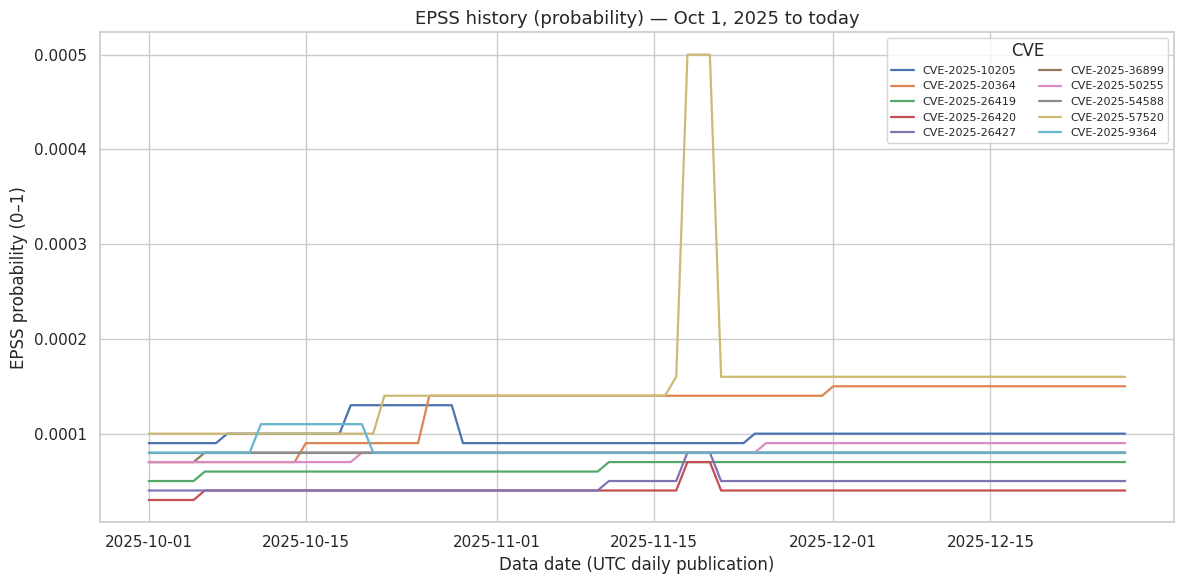

In [27]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=hist, x='date', y='epss', hue='cve', marker=None, linewidth=1.6)
ax.set_title('EPSS history (probability) — Oct 1, 2025 to today', fontsize=13)
ax.set_xlabel('Data date (UTC daily publication)')
ax.set_ylabel('EPSS probability (0–1)')
ax.legend(title='CVE', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()
